In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
ds = xr.open_dataset('entrainment_wam.zarr')

In [3]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 3249, cell: 39130)
Coordinates:
  * time     (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 313kB 1153007 1153011 1153012 ... 1286177 1286178
    lat      (cell) float64 313kB ...
    lon      (cell) float64 313kB ...
    crs      int64 8B ...
Data variables:
    cape     (time, cell) float32 509MB ...
    cin      (time, cell) float32 509MB ...
    lnb      (time, cell) float32 509MB ...
    t_lnb    (time, cell) float32 509MB ...
    tb       (time, cell) float32 509MB ...
    tb_diff  (time, cell) float32 509MB ...
    w_eff    (time, cell) float32 509MB ...

# Diurnal cycle over Burkina Faso

In [4]:
# Burkina Faso box: lat 9-15N, lon 355-5 (straddles 0 deg)
bf_mask = (ds.lat > 9) & (ds.lat < 15) & ((ds.lon > 355) | (ds.lon < 5))
ds_bf = ds.sel(cell=bf_mask)
print(f'Cells in box: {bf_mask.values.sum()}')

Cells in box: 4407


In [5]:
# Spatial mean over box then group by hour-of-day
ds_mean = ds_bf[['cape', 'lnb']].mean(dim='cell')

jja_mask = ds_mean.time.dt.month.isin([6, 7, 8])
djf_mask = ds_mean.time.dt.month.isin([12, 1, 2])

def diurnal_cycle(da):
    return da.groupby('time.hour').mean(), da.groupby('time.hour').std()

cape_jja_mean, cape_jja_std = diurnal_cycle(ds_mean.cape.sel(time=jja_mask))
cape_djf_mean, cape_djf_std = diurnal_cycle(ds_mean.cape.sel(time=djf_mask))
lnb_jja_mean,  lnb_jja_std  = diurnal_cycle(ds_mean.lnb.sel(time=jja_mask))
lnb_djf_mean,  lnb_djf_std  = diurnal_cycle(ds_mean.lnb.sel(time=djf_mask))

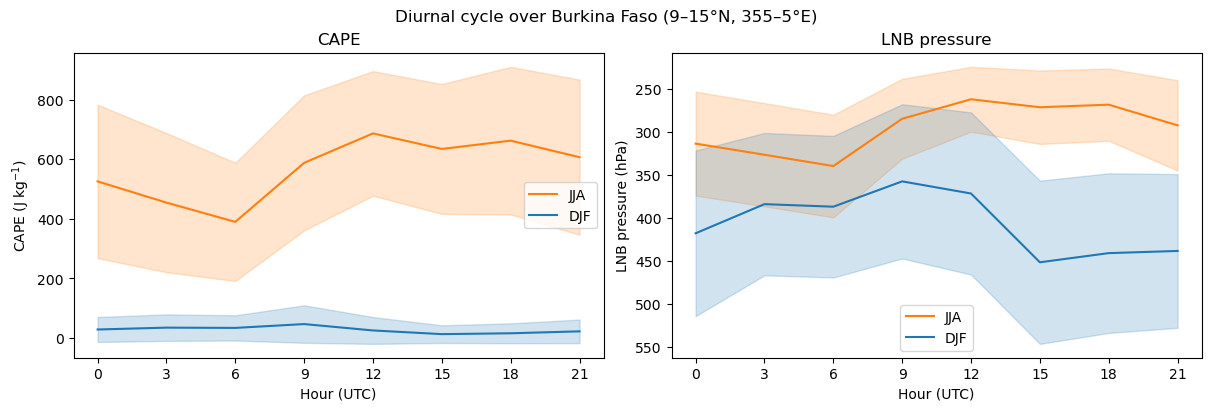

In [6]:
hours = cape_jja_mean.hour.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
fig.suptitle('Diurnal cycle over Burkina Faso (9–15°N, 355–5°E)')

# CAPE
for mean, std, label, color in [
    (cape_jja_mean, cape_jja_std, 'JJA', 'tab:orange'),
    (cape_djf_mean, cape_djf_std, 'DJF', 'tab:blue'),
]:
    ax1.plot(hours, mean, label=label, color=color)
    ax1.fill_between(hours, mean - std, mean + std, alpha=0.2, color=color)
ax1.set_xlabel('Hour (UTC)')
ax1.set_ylabel('CAPE (J kg$^{-1}$)')
ax1.set_xticks(hours)
ax1.legend()
ax1.set_title('CAPE')

# LNB pressure (lower pressure = higher altitude)
for mean, std, label, color in [
    (lnb_jja_mean, lnb_jja_std, 'JJA', 'tab:orange'),
    (lnb_djf_mean, lnb_djf_std, 'DJF', 'tab:blue'),
]:
    ax2.plot(hours, mean, label=label, color=color)
    ax2.fill_between(hours, mean - std, mean + std, alpha=0.2, color=color)
ax2.invert_yaxis()
ax2.set_xlabel('Hour (UTC)')
ax2.set_ylabel('LNB pressure (hPa)')
ax2.set_xticks(hours)
ax2.legend()
ax2.set_title('LNB pressure')

plt.show()